# Data Statistics

This notebook was used for visualizing several data statistics for the primary dataset. The dataset with all required columns (`all_data_set.csv`) can be found at [Zenodo](https://zenodo.org/records/14942335).

In [2]:
import matplotlib as mpl
from matplotlib import pyplot as plt
import seaborn as sns

rc = mpl.rc_params_from_file("/home/akshatz/.config/matplotlib/matplotlibrc", use_default_template=False)
sns.set_theme(style="white", rc=rc)
mpl.rcParams.update(rc)

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
all_data_set = pd.read_csv("dataset/all_data_set.csv")

In [5]:
all_data_set.columns

Index(['parent_smi', 'resonance_smis', 'num_resonance_structures',
       'multiplicity', 'H298', 'H298_kcal', 'subset', 'rdkit_mol',
       'num_heavy_atoms', 'mol_wt', 'num_rings', 'num_rotatable_bonds',
       'num_aromatic_rings', 'mol_graph_diameter', 'weights'],
      dtype='object')

In [6]:
all_data_set['subset']

0        non_resonance
1        non_resonance
2        non_resonance
3        non_resonance
4        non_resonance
             ...      
49995      res_radical
49996      res_radical
49997      res_radical
49998      res_radical
49999      res_radical
Name: subset, Length: 50000, dtype: object

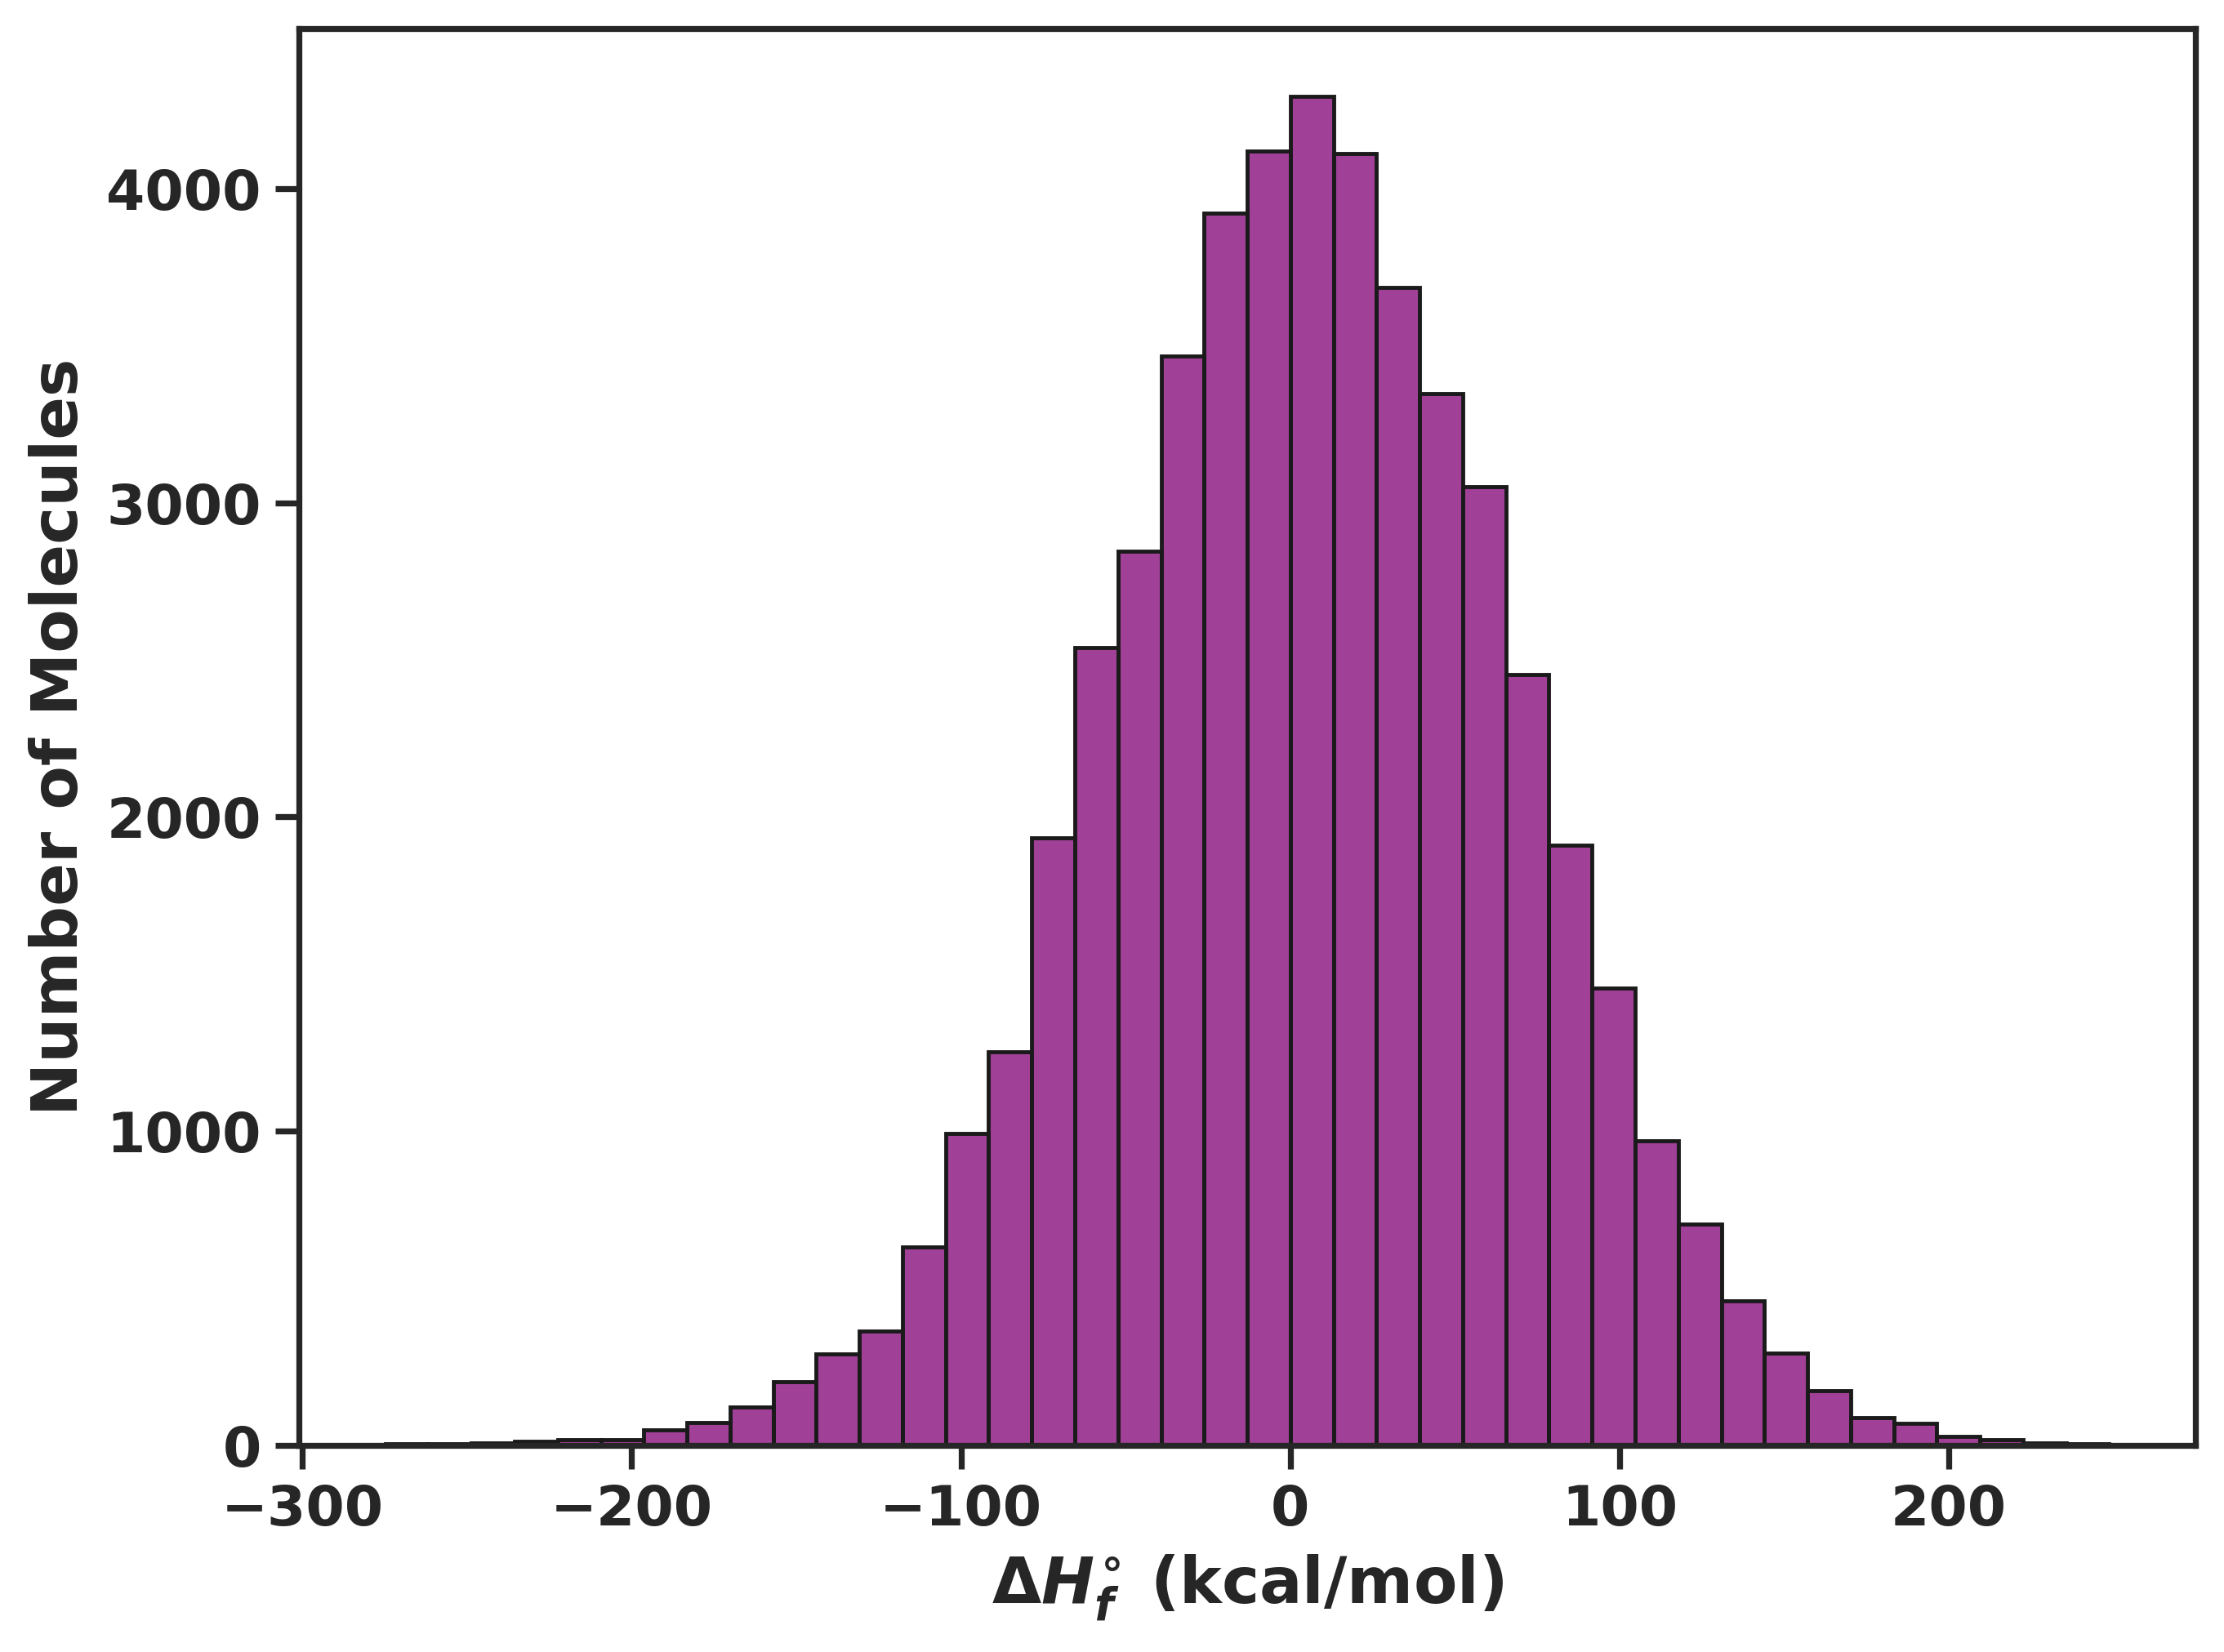

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas.api.types import CategoricalDtype

# Assuming all_data_set is already defined as your DataFrame

# Filter the data
df = all_data_set

# Create a distribution plot for the 'heat_of_formation' column
fig, ax1 = plt.subplots(1, 1, figsize=(8, 6), dpi=350)
sns.histplot(df['H298_kcal'], ax=ax1, kde=False, bins=40, color='#800074')

ax1.set_xlabel(r"$\Delta H_{f}^{\circ}$ (kcal/mol)")
ax1.set_ylabel('Number of Molecules')

plt.tight_layout()

fig.savefig("/home/akshatz/bond_order_free/figures_si/hf_data.pdf", bbox_inches="tight")

/tmp/ipykernel_594616/3402535758.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_resonance_group'] = df['num_resonance_structures'].apply(lambda x: '10+' if x >= 10 else str(x))
/tmp/ipykernel_594616/3402535758.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_resonance_group'] = df['num_resonance_group'].astype(category_type)
/tmp/ipykernel_594616/3402535758.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. P

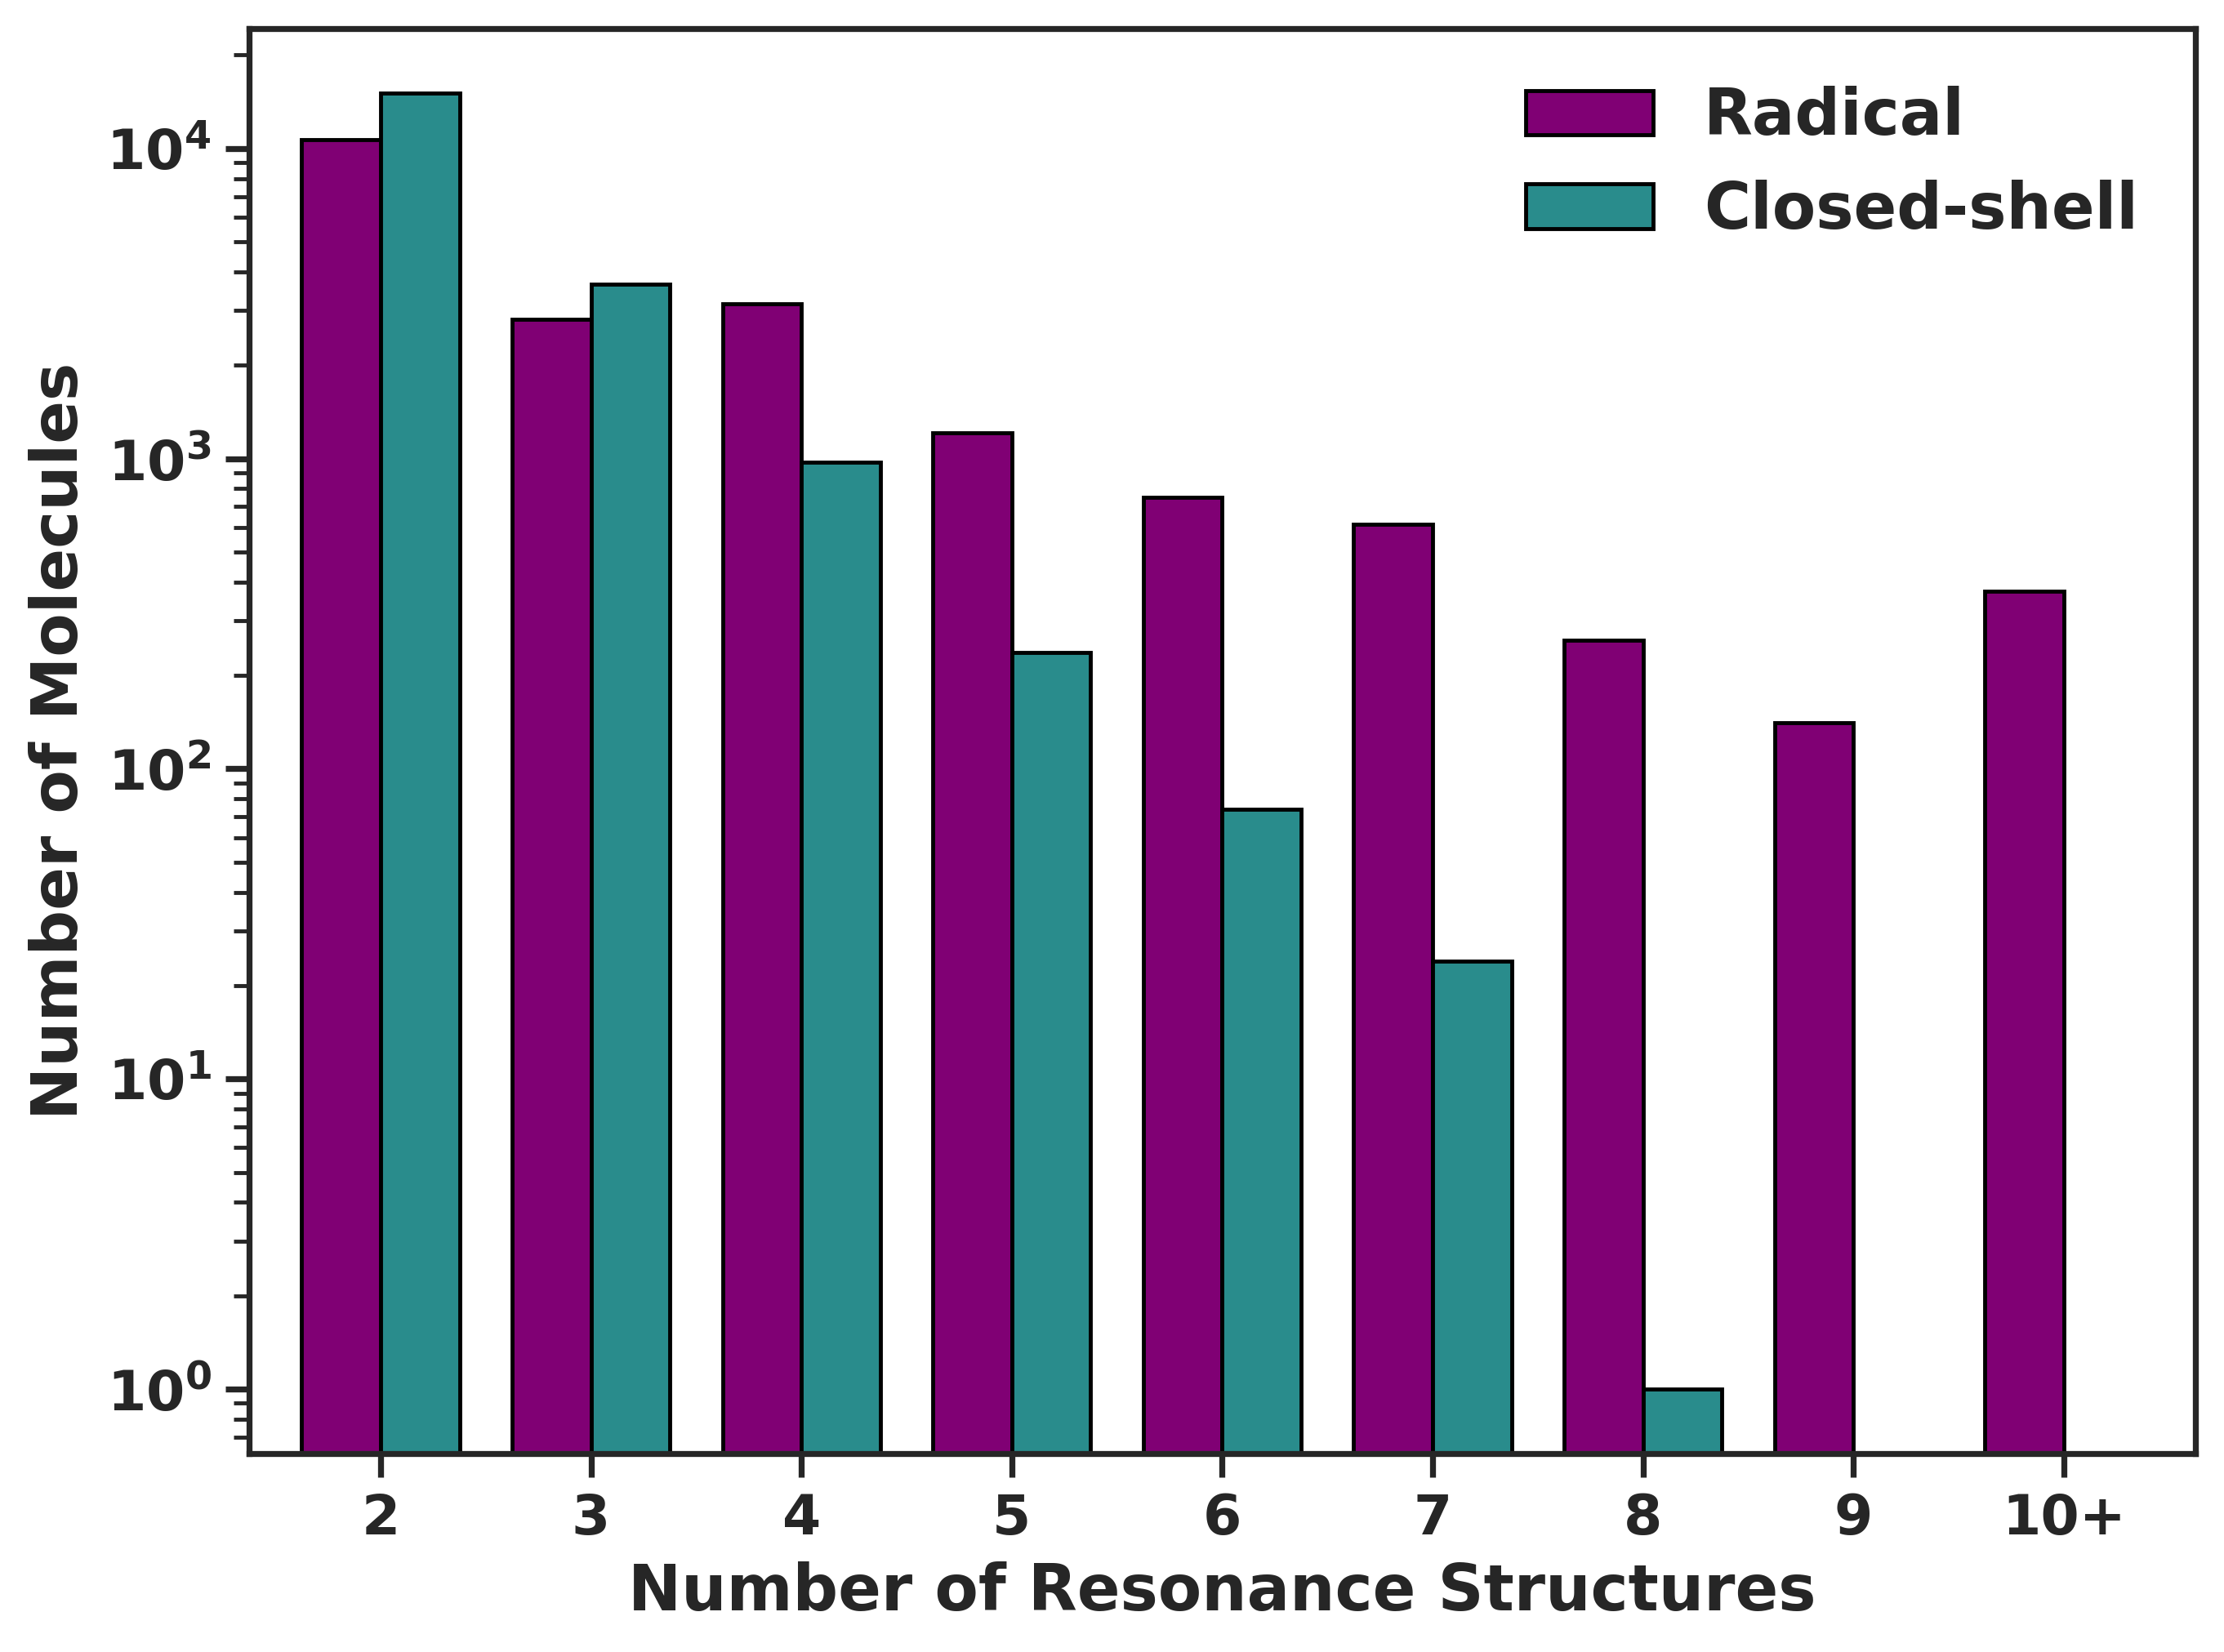

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas.api.types import CategoricalDtype

# Assuming all_data_set is already defined as your DataFrame

# Filter the data
df = all_data_set.query('(num_resonance_structures >= 2)')

# Create a new column to group resonance structures > 10
df['num_resonance_group'] = df['num_resonance_structures'].apply(lambda x: '10+' if x >= 10 else str(x))

# Define the correct order for the x-axis
category_order = [str(i) for i in range(2, 10)] + ['10+']
category_type = CategoricalDtype(categories=category_order, ordered=True)
df['num_resonance_group'] = df['num_resonance_group'].astype(category_type)

# Create a pivot table to count occurrences based on the new group
df_counts = df.groupby(['num_resonance_group', 'subset']).size().unstack(fill_value=0)

# Reorder the subsets as desired
desired_order = ['res_radical', 'res_closed_shell']
df_counts = df_counts[desired_order]
# display(df_counts)

# Create a figure and axis
fig, ax1 = plt.subplots(1, 1, figsize=(8, 6), dpi=350)

# Define the colors from the seaborn palette
colors = ['#800074', '#298c8c']

# Plot side-by-side bars (grouped bar plot)
bars = df_counts.plot(kind='bar', stacked=False, color=colors, ax=ax1, width=0.75, edgecolor='black')

# Add labels and title
ax1.set_xlabel('Number of Resonance Structures')
ax1.set_ylabel('Number of Molecules')
ax1.set_yscale('log')

# Adjust x-tick labels
ax1.set_xticklabels(df_counts.index, rotation=0)

# Customize the legend
custom_labels = ['Radical', 'Closed-shell']  # Your custom names
ax1.legend(custom_labels, frameon=False, loc='upper right')  # Place legend inside

# Show the plot
plt.tight_layout()

fig.savefig("/home/akshatz/bond_order_free/figures/resonance_data.pdf", bbox_inches="tight")
# fig.savefig("/home/akshatz/bond_order_free/figures/f2.svg")

## Data Stats

/tmp/ipykernel_594616/4145740110.py:14: UserWarning: 
The palette list has fewer values (1) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data=all_data_set.query('(num_resonance_structures >= 1) & (num_resonance_structures <= 15)'), x='num_resonance_structures', hue='num_resonance_structures', ax=ax1, palette=[mypalette1[1]], legend=False)
/tmp/ipykernel_594616/4145740110.py:24: UserWarning: 
The palette list has fewer values (1) than needed (12) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data=all_data_set.query('(num_heavy_atoms >= 6) & (num_heavy_atoms <= 17)'), x='num_heavy_atoms', hue='num_heavy_atoms', ax=ax2, palette=[mypalette1[4]], legend=False)
/tmp/ipykernel_594616/4145740110.py:34: UserWarning: 
The palette list has fewer values (1) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data=all_data_set, x='num_rings', hue='num_rings', ax=ax3, palette=[mypalette

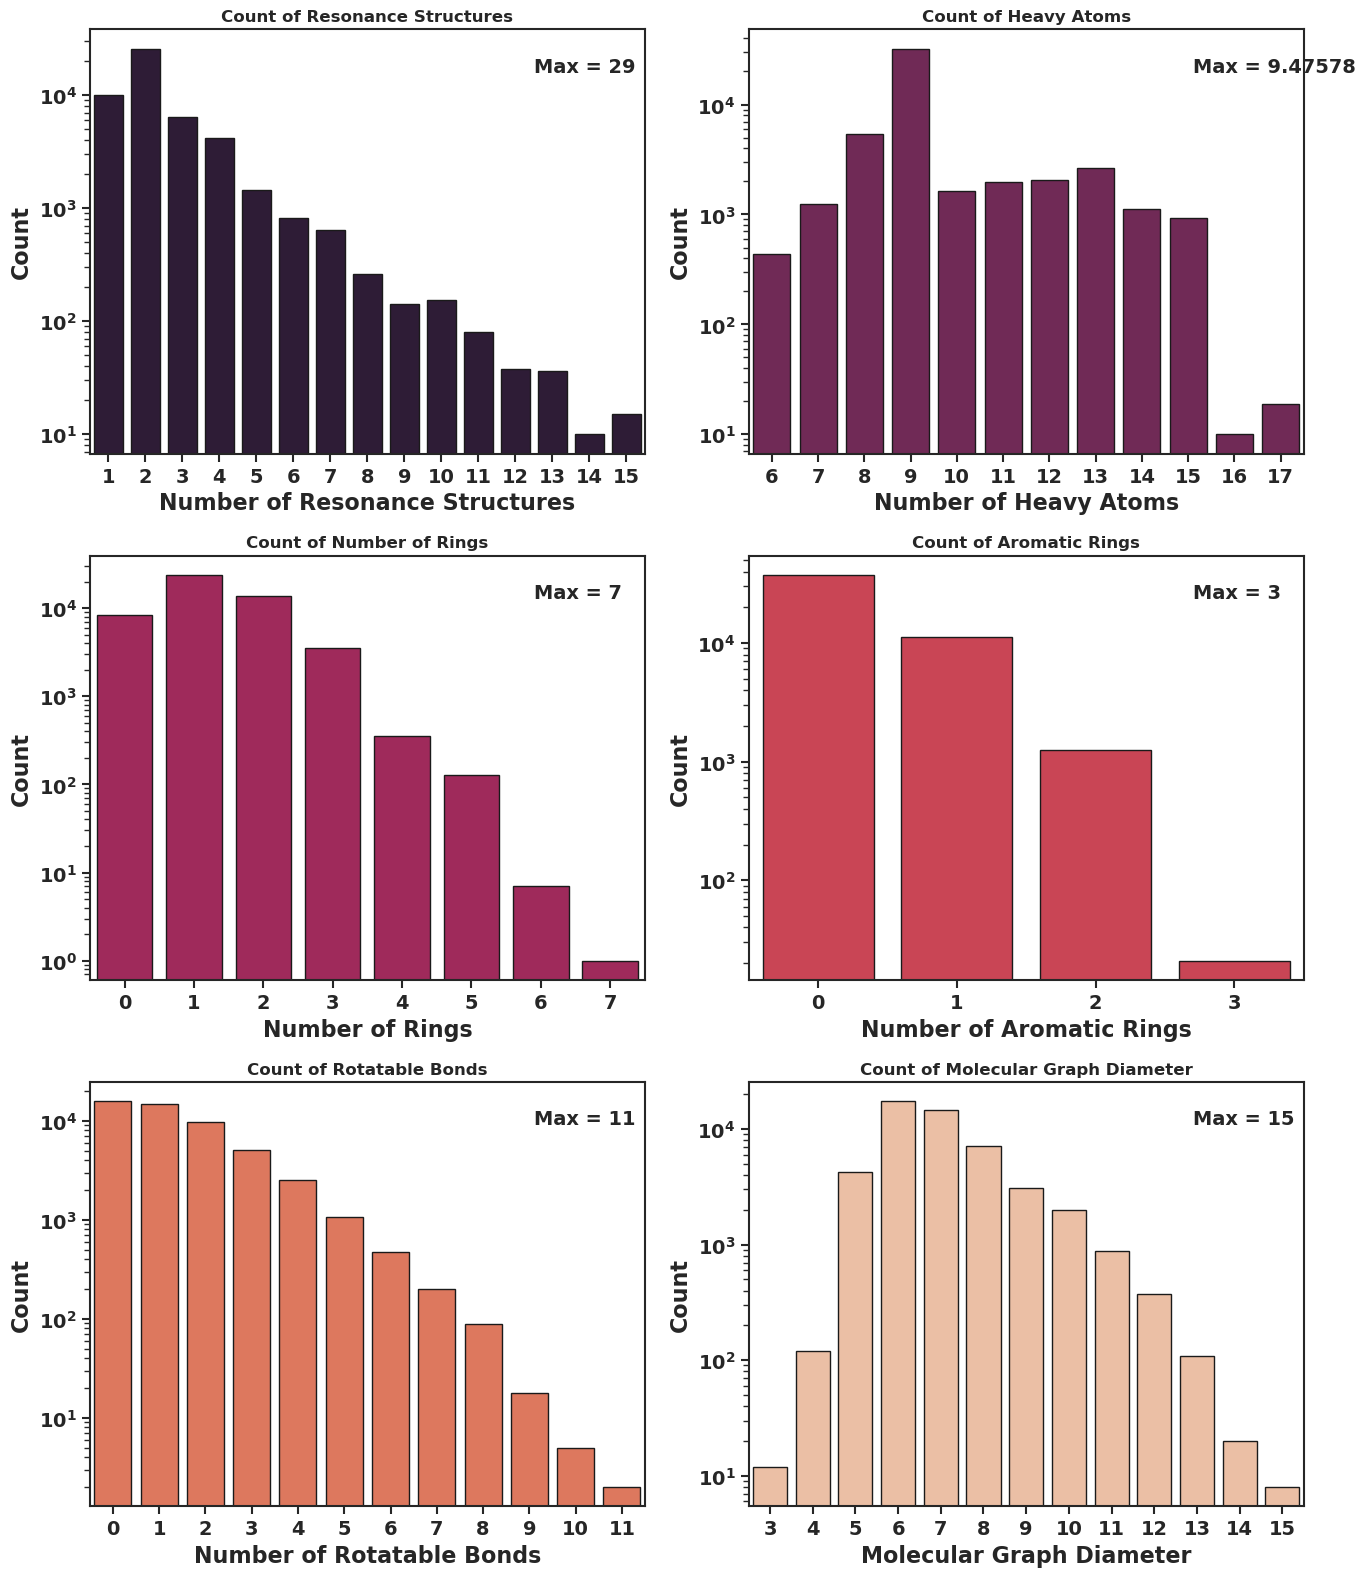

In [9]:
# Darker color palette
mypalette1 = sns.color_palette("rocket", 15)
mypalette2 = sns.color_palette("rocket", 12)
mypalette3 = sns.color_palette("rocket", 8)
mypalette4 = sns.color_palette("rocket", 4)
mypalette5 = sns.color_palette("rocket", 12)
mypalette6 = sns.color_palette("rocket", 13)



fig, ((ax1, ax2),(ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(14,16))

# Count plot for num_resonance_structures
sns.countplot(data=all_data_set.query('(num_resonance_structures >= 1) & (num_resonance_structures <= 15)'), x='num_resonance_structures', hue='num_resonance_structures', ax=ax1, palette=[mypalette1[1]], legend=False)
ax1.set_title('Count of Resonance Structures')
ax1.set_xlabel('Number of Resonance Structures')
ax1.set_ylabel('Count')
#ax1.set_xticks(rotation=45)
#ax1.set_xlim(-0.5, 14.5)
ax1.set_yscale('log')
ax1.text(0.8, 0.9, "Max = {}".format(all_data_set["num_resonance_structures"].max()), transform=ax1.transAxes)

# Count plot for num_heavy_atoms
sns.countplot(data=all_data_set.query('(num_heavy_atoms >= 6) & (num_heavy_atoms <= 17)'), x='num_heavy_atoms', hue='num_heavy_atoms', ax=ax2, palette=[mypalette1[4]], legend=False)
ax2.set_title('Count of Heavy Atoms')
ax2.set_xlabel('Number of Heavy Atoms')
ax2.set_ylabel('Count')
#ax2.set_xticks(rotation=45)
#ax2.set_xlim(3.5, 18.5)
ax2.set_yscale('log')
ax2.text(0.8, 0.9, "Max = {}".format(all_data_set["num_heavy_atoms"].mean()), transform=ax2.transAxes)

# Count of Rings
sns.countplot(data=all_data_set, x='num_rings', hue='num_rings', ax=ax3, palette=[mypalette1[6]], legend=False)
ax3.set_title('Count of Number of Rings')
ax3.set_xlabel('Number of Rings')
ax3.set_ylabel('Count')
#ax3.set_xticks(rotation=45)
#ax3.set_xlim(-0.5, 5.5)
ax3.set_yscale('log')
ax3.text(0.8, 0.9, "Max = {}".format(all_data_set["num_rings"].max()), transform=ax3.transAxes)

# Count of Aromatic Rings
sns.countplot(data=all_data_set, x='num_aromatic_rings', hue='num_aromatic_rings', ax=ax4, palette=[mypalette1[8]], legend=False)
ax4.set_title('Count of Aromatic Rings')
ax4.set_xlabel('Number of Aromatic Rings')
ax4.set_ylabel('Count')
#ax4.set_xticks(rotation=45)
#ax4.set_xlim(-0.5, 3.5)
ax4.set_yscale('log')
ax4.text(0.8, 0.9, "Max = {}".format(all_data_set["num_aromatic_rings"].max()), transform=ax4.transAxes)

# Count of Rotatable Bonds
sns.countplot(data=all_data_set, x='num_rotatable_bonds', hue='num_rotatable_bonds', ax=ax5, palette=[mypalette1[10]], legend=False)
ax5.set_title('Count of Rotatable Bonds')
ax5.set_xlabel('Number of Rotatable Bonds')
ax5.set_ylabel('Count')
ax5.set_yscale('log')
#ax5.set_xticks(rotation=45)
#ax5.set_xlim(3.5, 13.5)
ax5.text(0.8, 0.9, "Max = {}".format(all_data_set["num_rotatable_bonds"].max()), transform=ax5.transAxes)

# Max shortest distance
sns.countplot(data=all_data_set.query('(mol_graph_diameter >= 3)'), x='mol_graph_diameter', hue='mol_graph_diameter', ax=ax6, palette=[mypalette1[13]], legend=False)
ax6.set_title('Count of Molecular Graph Diameter', )
ax6.set_xlabel('Molecular Graph Diameter')
ax6.set_ylabel('Count')
ax6.set_yscale('log')
#ax6.set_xticklabels([int(x) for x in ax6.get_xticks()])
#ax6.set_xticks(rotation=45)
ax6.text(0.8, 0.9, "Max = {}".format(all_data_set["mol_graph_diameter"].max()), transform=ax6.transAxes)

plt.tight_layout()
plt.show()

/tmp/ipykernel_594616/2779289996.py:24: UserWarning: 
The palette list has fewer values (1) than needed (12) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data=all_data_set.query('(num_heavy_atoms >= 6) & (num_heavy_atoms <= 17)'), x='num_heavy_atoms', hue='num_heavy_atoms', ax=ax1, palette=[mypalette2[1]], legend=False)
/tmp/ipykernel_594616/2779289996.py:34: UserWarning: 
The palette list has fewer values (1) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data=all_data_set, x='num_rings', hue='num_rings', ax=ax2, palette=[mypalette2[1]], legend=False)
/tmp/ipykernel_594616/2779289996.py:45: UserWarning: 
The palette list has fewer values (1) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data=all_data_set, x='num_aromatic_rings', hue='num_aromatic_rings', ax=ax3, palette=[mypalette2[1]], legend=False)
/tmp/ipykernel_594616/2779289996.py:56: UserWarning: 
The palette li

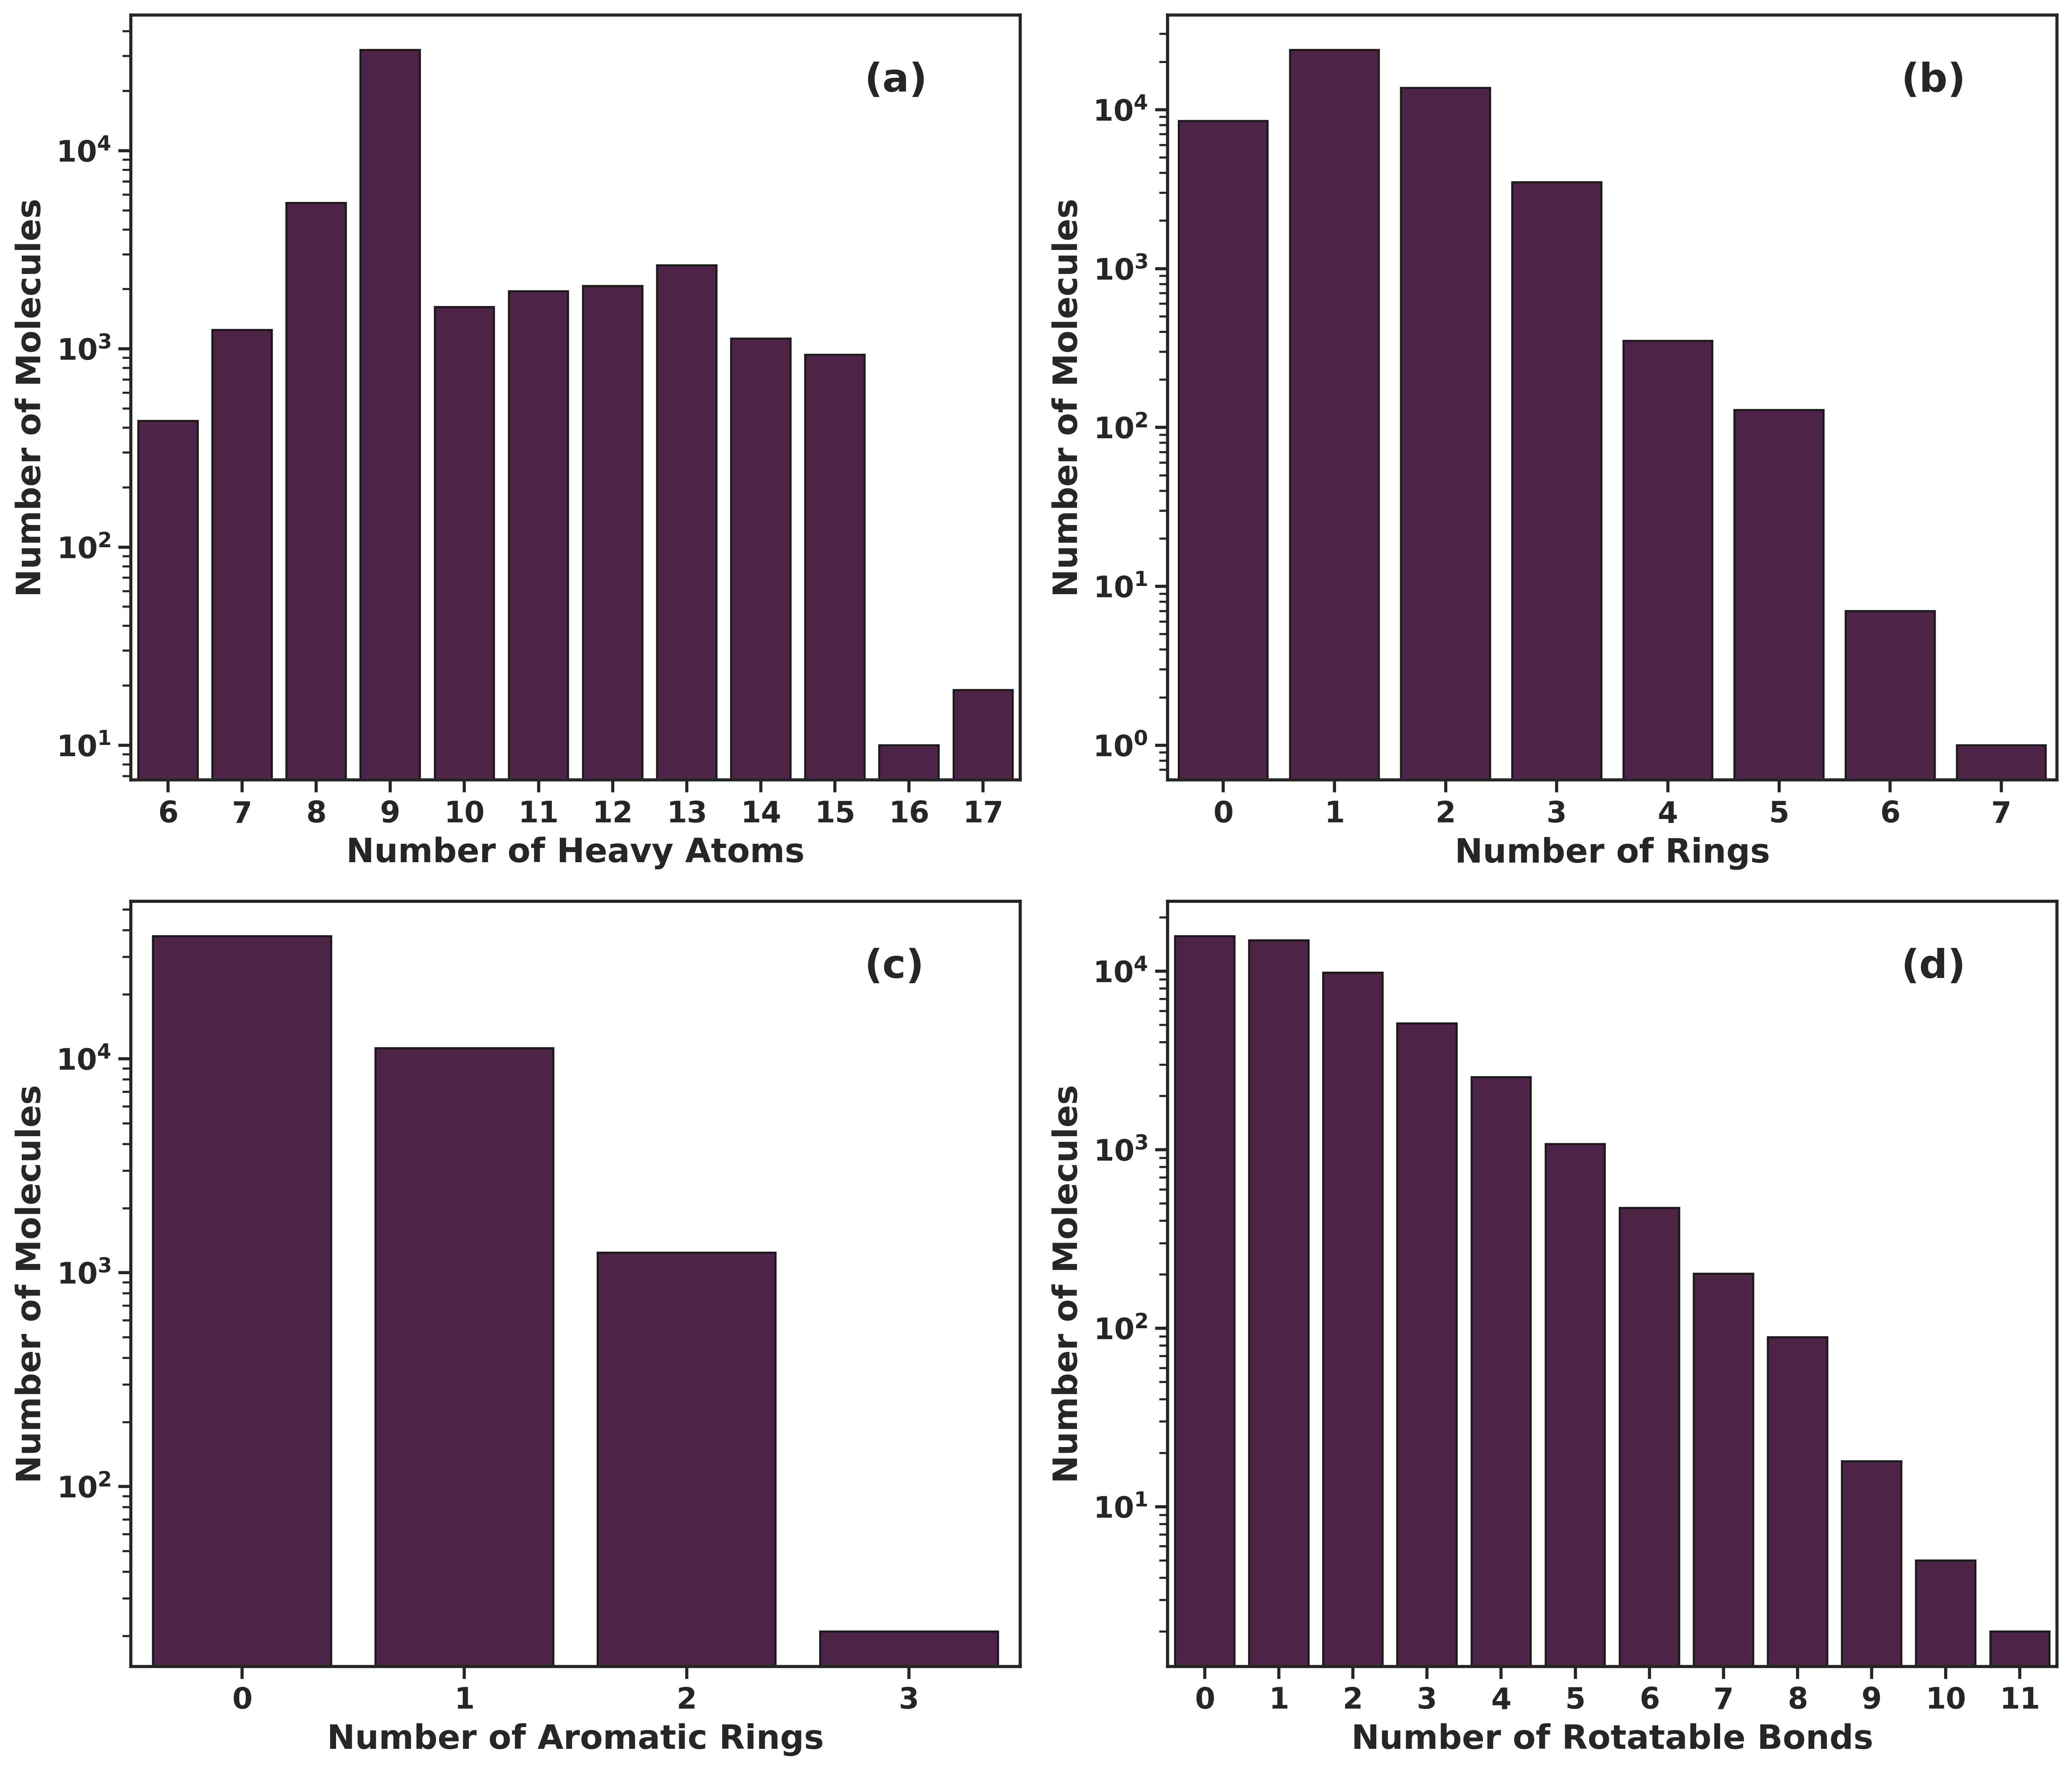

In [22]:
# Darker color palette
mypalette1 = sns.color_palette("rocket", 15)
mypalette2 = sns.color_palette("rocket", 8)
mypalette3 = sns.color_palette("rocket", 8)
mypalette4 = sns.color_palette("rocket", 4)
mypalette5 = sns.color_palette("rocket", 12)
mypalette6 = sns.color_palette("rocket", 13)



fig, ((ax1, ax2),(ax3, ax4)) = plt.subplots(2, 2, figsize=(14,12), dpi=400)

# Count plot for num_resonance_structures
# sns.countplot(data=all_data_set.query('(num_resonance_structures >= 1) & (num_resonance_structures <= 15)'), x='num_resonance_structures', hue='num_resonance_structures', ax=ax1, palette=[mypalette1[1]], legend=False)
# ax1.set_title('Count of Resonance Structures')
# ax1.set_xlabel('Number of Resonance Structures')
# ax1.set_ylabel('Count')
# #ax1.set_xticks(rotation=45)
# #ax1.set_xlim(-0.5, 14.5)
# ax1.set_yscale('log')
# ax1.text(0.8, 0.9, "Max = {}".format(all_data_set["num_resonance_structures"].max()), transform=ax1.transAxes)

# Count plot for num_heavy_atoms
sns.countplot(data=all_data_set.query('(num_heavy_atoms >= 6) & (num_heavy_atoms <= 17)'), x='num_heavy_atoms', hue='num_heavy_atoms', ax=ax1, palette=[mypalette2[1]], legend=False)
# ax1.set_title('Count of Heavy Atoms')
ax1.set_xlabel('Number of Heavy Atoms')
ax1.set_ylabel('Number of Molecules')
#ax2.set_xticks(rotation=45)
#ax2.set_xlim(3.5, 18.5)
ax1.set_yscale('log')
ax1.text(0.825, 0.9, "(a)", transform=ax1.transAxes, fontsize=19)

# Count of Rings
sns.countplot(data=all_data_set, x='num_rings', hue='num_rings', ax=ax2, palette=[mypalette2[1]], legend=False)
# ax2.set_title('Count of Number of Rings')
ax2.set_xlabel('Number of Rings')
ax2.set_ylabel('Number of Molecules')
#ax3.set_xticks(rotation=45)
#ax3.set_xlim(-0.5, 5.5)
ax2.set_yscale('log')
ax2.text(0.825, 0.9, "(b)", transform=ax2.transAxes, fontsize=19)
#ax3.text(0.8, 0.9, "Max = {}".format(all_data_set["num_rings"].max()), transform=ax3.transAxes)

# Count of Aromatic Rings
sns.countplot(data=all_data_set, x='num_aromatic_rings', hue='num_aromatic_rings', ax=ax3, palette=[mypalette2[1]], legend=False)
# ax3.set_title('Count of Aromatic Rings')
ax3.set_xlabel('Number of Aromatic Rings')
ax3.set_ylabel('Number of Molecules')
#ax4.set_xticks(rotation=45)
#ax4.set_xlim(-0.5, 3.5)
ax3.set_yscale('log')
ax3.text(0.825, 0.9, "(c)", transform=ax3.transAxes, fontsize=19)
#ax4.text(0.8, 0.9, "Max = {}".format(all_data_set["num_aromatic_rings"].max()), transform=ax4.transAxes)

# Count of Rotatable Bonds
sns.countplot(data=all_data_set, x='num_rotatable_bonds', hue='num_rotatable_bonds', ax=ax4, palette=[mypalette2[1]], legend=False)
# ax4.set_title('Count of Rotatable Bonds')
ax4.set_xlabel('Number of Rotatable Bonds')
ax4.set_ylabel('Number of Molecules')
ax4.set_yscale('log')
ax4.text(0.825, 0.9, "(d)", transform=ax4.transAxes, fontsize=19)
#ax5.set_xticks(rotation=45)
#ax5.set_xlim(3.5, 13.5)
#ax5.text(0.8, 0.9, "Max = {}".format(all_data_set["num_rotatable_bonds"].max()), transform=ax5.transAxes)

# Max shortest distance
# sns.countplot(data=all_data_set.query('(mol_graph_diameter >= 3)'), x='mol_graph_diameter', hue='mol_graph_diameter', ax=ax6, palette=[mypalette1[13]], legend=False)
# ax6.set_title('Count of Molecular Graph Diameter', )
# ax6.set_xlabel('Molecular Graph Diameter')
# ax6.set_ylabel('Count')
# ax6.set_yscale('log')
#ax6.set_xticklabels([int(x) for x in ax6.get_xticks()])
#ax6.set_xticks(rotation=45)
#ax6.text(0.8, 0.9, "Max = {}".format(all_data_set["mol_graph_diameter"].max()), transform=ax6.transAxes)

fig.tight_layout()
fig.savefig("/home/akshatz/bond_order_free/figures_si/data_statistics.pdf", bbox_inches="tight")

In [18]:
mypalette2

[(0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
 (0.8666666666666667, 0.5176470588235295, 0.3215686274509804),
 (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
 (0.7686274509803922, 0.3058823529411765, 0.3215686274509804)]

/tmp/ipykernel_3117739/2062338329.py:11: UserWarning: 
The palette list has fewer values (1) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data=all_data_set.query('(num_resonance_structures >= 1) & (num_resonance_structures <= 15)'), x='num_resonance_structures', hue='num_resonance_structures', ax=ax1, palette=[mypalette1[4]], legend=False)


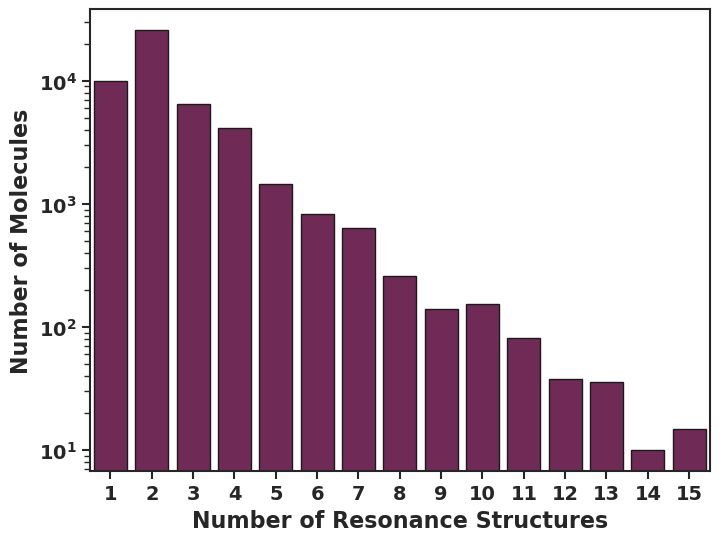

In [22]:
# Darker color palette
mypalette1 = sns.color_palette("rocket", 15)

fig, ax1 = plt.subplots(1, 1, figsize=(8,6))

# Set y-axis to log scale
# ax1.set_yscale('symlog')
# ax2.set_yscale('symlog')

# Count plot for num_resonance_structures
sns.countplot(data=all_data_set.query('(num_resonance_structures >= 1) & (num_resonance_structures <= 15)'), x='num_resonance_structures', hue='num_resonance_structures', ax=ax1, palette=[mypalette1[4]], legend=False)
ax1.set_xlabel('Number of Resonance Structures')
ax1.set_ylabel('Number of Molecules')
ax1.set_yscale('log')
#ax1.set_xticks(rotation=45)
#ax1.set_xlim(-0.5, 14.5)
# fig.savefig("/home/akshatz/bond_order_free/figures/f2a.pdf", bbox_inches="tight")

/tmp/ipykernel_3117739/470490739.py:3: UserWarning: 
The palette list has fewer values (1) than needed (12) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data=all_data_set.query('(num_heavy_atoms >= 6) & (num_heavy_atoms <= 17)'), x='num_heavy_atoms', hue='num_heavy_atoms', ax=ax2, palette=[mypalette1[1]], legend=False)


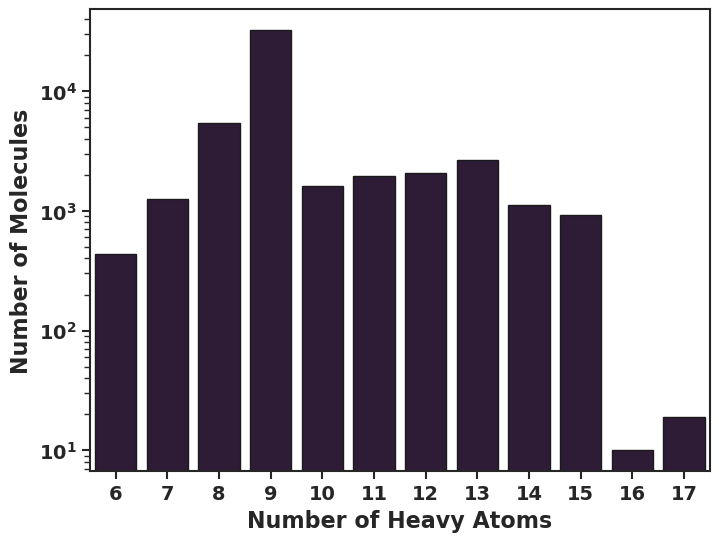

In [23]:
fig, ax2 = plt.subplots(1, 1, figsize=(8,6))

sns.countplot(data=all_data_set.query('(num_heavy_atoms >= 6) & (num_heavy_atoms <= 17)'), x='num_heavy_atoms', hue='num_heavy_atoms', ax=ax2, palette=[mypalette1[1]], legend=False)
ax2.set_xlabel('Number of Heavy Atoms')
ax2.set_ylabel('Number of Molecules')
#ax2.set_xticks(rotation=45)
#ax2.set_xlim(3.5, 18.5)
ax2.set_yscale('log')

# fig.savefig("/home/akshatz/bond_order_free/figures/f2b.pdf", bbox_inches="tight")